# 音频零基础 6/6：真实 WAV：读取、试听、可视化与输入审计

这节课从生活中的声音出发，再落到 Python 数组。**先建立直觉，再看公式，最后用代码验证。**

| 项目 | 内容 |
|---|---|
| 本课要回答的问题 | 拿到一条 WAV 后，怎样先确认它是什么，再交给 ASR？ |
| 前置要求 | 会运行 Notebook；看不懂代码时先读 Python/PyTorch 基础 1～3 |
| 建议投入 | 90～120 分钟，分成“直觉”和“代码”两次完成也可以 |
| 四个关键词 | WAV、元数据、波形审计、输入契约 |
| 通关证据 | 能用自己的话解释、能算一个数字例子、能画图验证、能从空白实现核心函数 |

本课不是词汇表。每出现一个量，都要写清楚：**它描述什么、单位是什么、数组中怎样表示、改变后听觉或图形怎样变化。**


## 课前回忆：先写猜测，不查答案

1. 对问题“拿到一条 WAV 后，怎样先确认它是什么，再交给 ASR？”写下你现在的答案；不会就写“不知道”。
2. 四个关键词中，圈出最陌生的一个：WAV / 元数据 / 波形审计 / 输入契约。
3. 画一条横轴是时间的线，标出 0 秒、0.5 秒和 1 秒。
4. 写下一个可验证的预测：如果把声音的某个参数加倍，图或听感会怎样？

学完后回到这里，用另一种颜色修正。保留错误猜测，它是学习证据。


## 固定观察框架：物理世界 → 数字 → 图 → 听感

```text
声源振动 → 空气压力随时间变化 → 麦克风电信号 → 离散采样值 x[n]
                                                ↓
                                      波形 / 数值统计 / 频谱
```

后面所有 ASR 前端课都沿这条链展开。波形不是声音本身，而是麦克风在一串离散时刻记录下来的数字。


## 1. 读取前先明确路径，读取后先看元数据

这节使用仓库自带的 FSDD 数字语音。不要先画复杂图，先确认采样率、shape、dtype 和时长。


In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
audio_path = ROOT / "data" / "0_jackson_0.wav"
audio, sample_rate = sf.read(audio_path, dtype="float32", always_2d=False)

print("path:", audio_path)
print("sample_rate:", sample_rate, "Hz")
print("shape/dtype:", audio.shape, audio.dtype)
print("duration:", len(audio) / sample_rate, "seconds")
assert audio.ndim == 1


path: <REPO_ROOT>\data\0_jackson_0.wav
sample_rate: 8000 Hz
shape/dtype: (5148,) float32
duration: 0.6435 seconds


## 2. 试听是证据之一，但不能代替测量

扬声器和音量设置会影响听感；代码仍要审计数值。


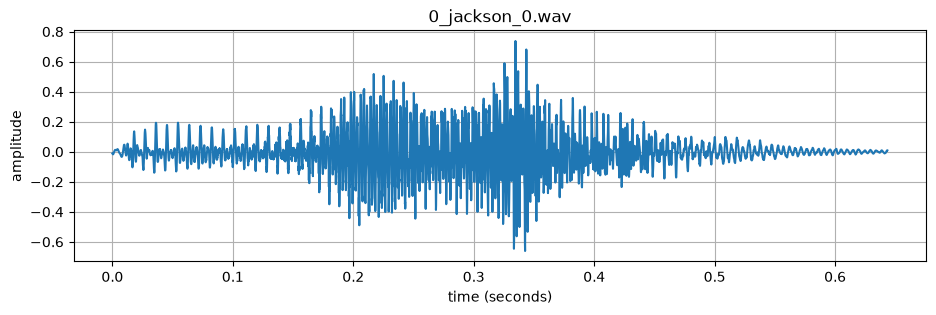

In [2]:
display(Audio(audio, rate=sample_rate))

time_seconds = np.arange(len(audio)) / sample_rate
plt.figure(figsize=(11, 3))
plt.plot(time_seconds, audio)
plt.xlabel("time (seconds)")
plt.ylabel("amplitude")
plt.title(audio_path.name)
plt.grid(True)
plt.show()


## 3. 写一个最小输入审计器

审计器不判断“识别一定好不好”，只检查输入是否满足明确契约，并暴露风险信号。


In [3]:
def audit_waveform(waveform: np.ndarray, sample_rate_hz: int) -> dict:
    waveform = np.asarray(waveform)
    if waveform.ndim not in {1, 2}:
        raise ValueError(f"expected [T] or [T,C], got {waveform.shape}")
    if waveform.shape[0] == 0:
        raise ValueError("waveform must not be empty")
    if sample_rate_hz <= 0:
        raise ValueError("sample rate must be positive")
    values = waveform.astype(np.float64)
    return {
        "sample_rate_hz": sample_rate_hz,
        "channels": 1 if waveform.ndim == 1 else waveform.shape[1],
        "samples_per_channel": waveform.shape[0],
        "duration_seconds": waveform.shape[0] / sample_rate_hz,
        "dtype": str(waveform.dtype),
        "peak": float(np.max(np.abs(values))),
        "rms": float(np.sqrt(np.mean(values ** 2))),
        "dc": float(np.mean(values)),
        "clipped_ratio": float(np.mean(np.abs(values) >= 0.999)),
        "finite": bool(np.isfinite(values).all()),
    }


report = audit_waveform(audio, sample_rate)
for key, value in report.items():
    print(f"{key:20s}: {value}")


sample_rate_hz      : 8000
channels            : 1
samples_per_channel : 5148
duration_seconds    : 0.6435
dtype               : float32
peak                : 0.737396240234375
rms                 : 0.13679308475688584
dc                  : -7.244071575126263e-06
clipped_ratio       : 0.0
finite              : True


## 4. 错误元数据会改变时间解释

同一数组如果误标采样率，样本值没变，但时长、音高和后续帧数解释都会错。


In [4]:
for claimed_rate in [sample_rate // 2, sample_rate, sample_rate * 2]:
    claimed_duration = len(audio) / claimed_rate
    print(f"claimed rate={claimed_rate:5d} Hz -> claimed duration={claimed_duration:.3f} s")

assert np.isclose(report["duration_seconds"], len(audio) / sample_rate)
assert report["finite"]
assert report["peak"] <= 1.0


claimed rate= 4000 Hz -> claimed duration=1.287 s
claimed rate= 8000 Hz -> claimed duration=0.643 s
claimed rate=16000 Hz -> claimed duration=0.322 s


## 5. 把审计结果变成明确的入口门槛

生产系统的门槛取决于模型契约。教学示例只接受单声道、8 kHz、有限浮点数；不要把这些数字误当成所有 ASR 的通用标准。


In [5]:
def require_teaching_input(report: dict) -> None:
    if report["channels"] != 1:
        raise ValueError("this lesson expects mono audio")
    if report["sample_rate_hz"] != 8_000:
        raise ValueError("this lesson expects 8 kHz audio")
    if not report["finite"]:
        raise ValueError("waveform contains NaN or infinity")
    if report["peak"] > 1.0:
        raise ValueError("normalized float waveform is outside [-1, 1]")


require_teaching_input(report)
print("teaching input contract passed")


teaching input contract passed


## 分层练习：不要一次做完

### A. 直觉与单位（每题 1 分）

1. 不看上文，用一句话定义：WAV。
2. 为 `元数据` 写出单位；如果它没有单位，要明确说明。
3. 举一个生活中的例子解释 `波形审计`。
4. 画图说明 `输入契约` 增大时，横轴或纵轴怎样变化。

### B. 数字与预测（每题 2 分）

5. 自己构造一个包含具体数字的计算例子，并标出每一步单位。
6. 把本课一个参数改成 0.5 倍和 2 倍；运行前先画出预期图形。
7. 找出一个“代码能运行，但物理含义错误”的输入，解释为什么错误。
8. 用 `shape / dtype / min / max` 四项审计本课最重要的数组。

### C. 实现与迁移（每题 3 分）

9. 从空白实现：**从空白实现 audit_waveform，并用空数组、立体声、NaN 和错误采样率做故障注入**，不能复制上面的函数。
10. 为实现写正常、边界和错误输入三类测试。
11. 换一组参数或换一条音频，验证结论是否仍成立。
12. 用 90 秒向没学过编程的人解释本课，只允许使用两个术语，并必须包含一个数字例子。

满分 24 分。达到 19 分且第 9～10 题完成，才建议继续；15～18 分次日重做；低于 15 分先回到图和单位。


## 最小掌握门禁

- [ ] 我能把本课每个量说成“含义 + 单位 + 数组表示”。
- [ ] 我能在运行前预测参数变化的方向。
- [ ] 我能从空白完成核心实现并覆盖边界输入。
- [ ] 我能说出一个常见误解，以及用什么证据推翻它。
- [ ] 我已把错题写入根目录 `LEARNING_LOG.md`，并安排明天、7 天、30 天复习。

下一步：进入 ASR 主线第 1 课《声音与采样》，把这些直觉用于采样定理、混叠和真实语音。
